In [22]:
pip install pandas textblob matplotlib wordcloud

In [23]:
# NETFLIX CUSTOMER SENTIMENT ANALYSIS

import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

plt.style.use("ggplot")

NETFLIX_RED = "#E50914"
NETFLIX_BLACK = "#221F1F"
NETFLIX_GRAY = "#B3B3B3"
POSITIVE_GREEN = "#2E8B57"


In [24]:
# ---- Settings ----
CSV_FILE = "netflix_reviews.csv"
TEXT_COLUMN = "content"
DATE_COLUMN = "at"
RATING_COLUMN = "score"
PRICE_HIKE_DATE = "2026-03-16"

In [25]:
# ---- Load and clean data ----
data = pd.read_csv(CSV_FILE, engine="python", on_bad_lines="warn")
data[DATE_COLUMN] = pd.to_datetime(data[DATE_COLUMN], errors="coerce", dayfirst=True)
data = data.dropna(subset=[TEXT_COLUMN, DATE_COLUMN])
print("✅ Rows after cleaning:", len(data))

✅ Rows after cleaning: 157624


In [26]:
# ---- Assign Before/After period ----
price_hike_date = pd.to_datetime(PRICE_HIKE_DATE)

def assign_period(review_date):
    if review_date < price_hike_date:
        return "Before Price Hike"
    return "After Price Hike"

data["Period"] = data[DATE_COLUMN].apply(assign_period)
print("📅 Reviews per period:\n", data["Period"].value_counts())

📅 Reviews per period:
 Period
Before Price Hike    147978
After Price Hike       9646
Name: count, dtype: int64


In [27]:
# ---- Sentiment and subjectivity ----
def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

def get_subjectivity(text):
    return TextBlob(str(text)).sentiment.subjectivity

def sentiment_label(score):
    if score > 0:
        return "positive"
    elif score < 0:
        return "negative"
    return "neutral"

data["Predicted_Sentiment_Score"] = data[TEXT_COLUMN].apply(get_polarity)
data["Predicted_Sentiment_Label"] = data["Predicted_Sentiment_Score"].apply(sentiment_label)
data["Subjectivity_Score"] = data[TEXT_COLUMN].apply(get_subjectivity)

In [28]:
# ---- Validate against star rating ----
def expected_from_rating(rating):
    if rating >= 4:
        return "positive"
    elif rating <= 2:
        return "negative"
    return "neutral"

data["Expected_From_Rating"] = data[RATING_COLUMN].apply(expected_from_rating)
agreement_rate = round((data["Predicted_Sentiment_Label"] == data["Expected_From_Rating"]).mean() * 100, 1)
print(f"🎯 Model agreement with star ratings: {agreement_rate}%")

ratings = sorted(data[RATING_COLUMN].unique())
positive_counts, negative_counts, neutral_counts = [], [], []
for rating in ratings:
    subset = data[data[RATING_COLUMN] == rating]
    positive_counts.append((subset["Predicted_Sentiment_Label"] == "positive").sum())
    negative_counts.append((subset["Predicted_Sentiment_Label"] == "negative").sum())
    neutral_counts.append((subset["Predicted_Sentiment_Label"] == "neutral").sum())


🎯 Model agreement with star ratings: 56.0%


In [29]:
# ---- Overall and Before/After sentiment percentages ----
sentiment_counts = data["Predicted_Sentiment_Label"].value_counts()
sentiment_percentages = (sentiment_counts / len(data) * 100).round(1)

before_data = data[data["Period"] == "Before Price Hike"]
after_data = data[data["Period"] == "After Price Hike"]
before_pct = (before_data["Predicted_Sentiment_Label"].value_counts() / len(before_data) * 100).round(1)
after_pct = (after_data["Predicted_Sentiment_Label"].value_counts() / len(after_data) * 100).round(1)
print("📊 Sentiment % — Before:", dict(before_pct))
print("📊 Sentiment % — After:", dict(after_pct))

📊 Sentiment % — Before: {'positive': np.float64(58.6), 'negative': np.float64(23.0), 'neutral': np.float64(18.4)}
📊 Sentiment % — After: {'positive': np.float64(57.9), 'neutral': np.float64(26.4), 'negative': np.float64(15.7)}


In [30]:
# ---- Equal-length window comparison (fairer than using all history) ----
after_duration = data[DATE_COLUMN].max() - price_hike_date
equal_window_start = price_hike_date - after_duration
before_equal = data[(data[DATE_COLUMN] >= equal_window_start) & (data[DATE_COLUMN] < price_hike_date)]
before_equal_pct = (before_equal["Predicted_Sentiment_Label"].value_counts() / len(before_equal) * 100).round(1)
print("📊 Sentiment % — Before (equal-length window):", dict(before_equal_pct))

change = round(after_pct.get("negative", 0) - before_pct.get("negative", 0), 1)
print(f"💡 INSIGHT: Negative sentiment went from {before_pct.get('negative', 0)}% to "
      f"{after_pct.get('negative', 0)}% after the price increase (change of {change} points).")

📊 Sentiment % — Before (equal-length window): {'positive': np.float64(53.5), 'neutral': np.float64(27.0), 'negative': np.float64(19.5)}
💡 INSIGHT: Negative sentiment went from 23.0% to 15.7% after the price increase (change of -7.3 points).


In [31]:
# ==================== Charts ====================

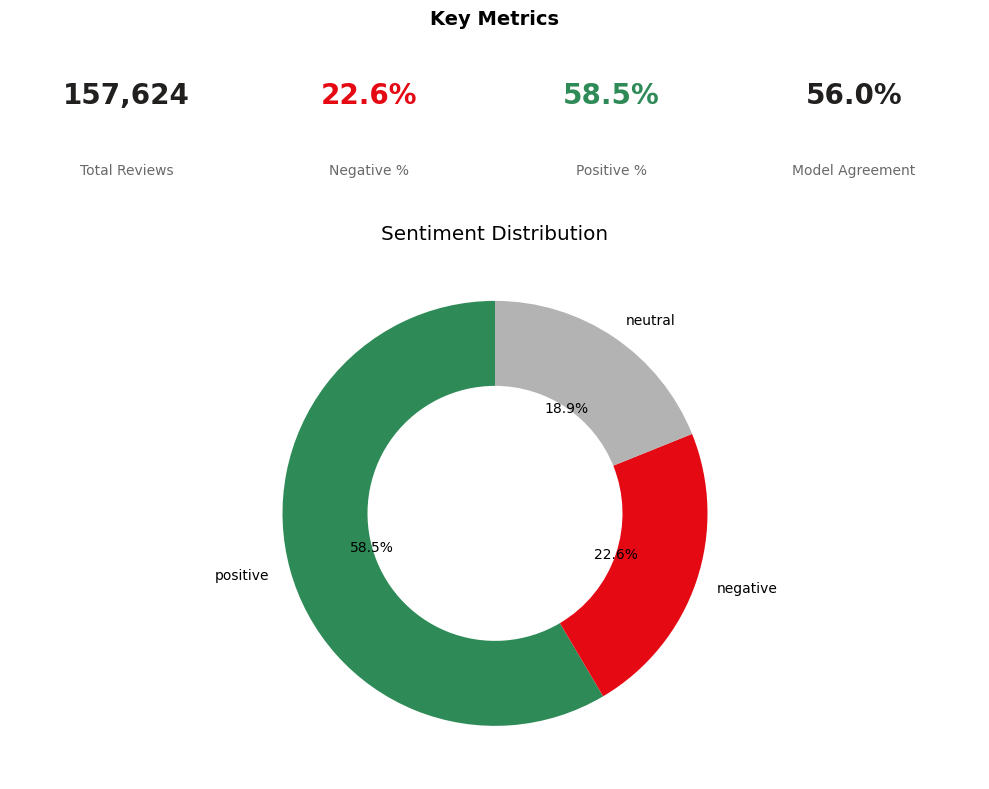

In [32]:
# Key metrics + sentiment donut
fig, axes = plt.subplots(2, 1, figsize=(10, 8), height_ratios=[1, 3])
axes[0].axis("off")
axes[0].set_title("Key Metrics", fontsize=14, fontweight="bold")
kpi_data = [
    ("Total Reviews", f"{len(data):,}", NETFLIX_BLACK),
    ("Negative %", f"{sentiment_percentages.get('negative', 0)}%", NETFLIX_RED),
    ("Positive %", f"{sentiment_percentages.get('positive', 0)}%", POSITIVE_GREEN),
    ("Model Agreement", f"{agreement_rate}%", NETFLIX_BLACK),
]
for i, (label, value, color) in enumerate(kpi_data):
    x = 0.12 + i * 0.25
    axes[0].text(x, 0.6, value, ha="center", fontsize=20, fontweight="bold", color=color)
    axes[0].text(x, 0.2, label, ha="center", fontsize=10, color="dimgray")

colors = [NETFLIX_RED if s == "negative" else POSITIVE_GREEN if s == "positive" else NETFLIX_GRAY
          for s in sentiment_percentages.index]
axes[1].pie(sentiment_percentages, labels=sentiment_percentages.index, autopct="%1.1f%%",
            startangle=90, colors=colors, wedgeprops=dict(width=0.4))
axes[1].set_title("Sentiment Distribution")
plt.tight_layout()
plt.savefig("key_metrics_and_donut.png", dpi=150, bbox_inches="tight")
plt.show()

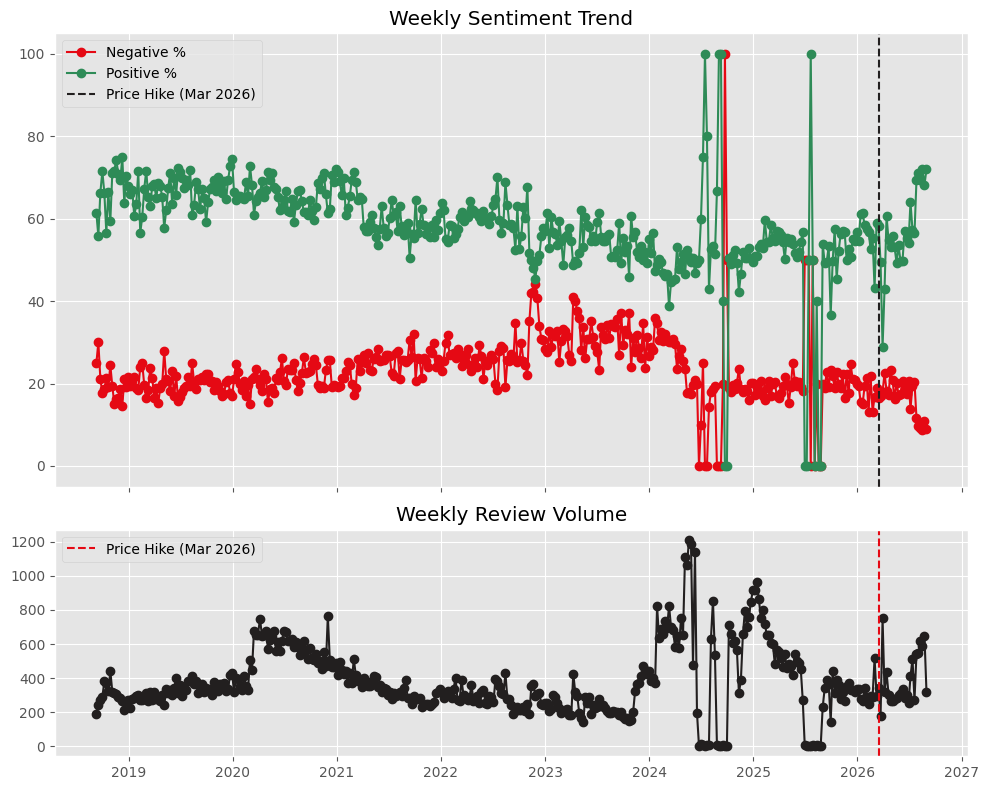

In [33]:
# Weekly sentiment trend + review volume
data["Week"] = data[DATE_COLUMN].dt.to_period("W").dt.start_time
weeks = sorted(data["Week"].unique())
weekly_total, weekly_neg_pct, weekly_pos_pct = [], [], []
for week in weeks:
    week_data = data[data["Week"] == week]
    total = len(week_data)
    weekly_total.append(total)
    weekly_neg_pct.append(round((week_data["Predicted_Sentiment_Label"] == "negative").sum() / total * 100, 1) if total else 0)
    weekly_pos_pct.append(round((week_data["Predicted_Sentiment_Label"] == "positive").sum() / total * 100, 1) if total else 0)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), height_ratios=[2, 1], sharex=True)
axes[0].plot(weeks, weekly_neg_pct, marker="o", color=NETFLIX_RED, label="Negative %")
axes[0].plot(weeks, weekly_pos_pct, marker="o", color=POSITIVE_GREEN, label="Positive %")
axes[0].axvline(price_hike_date, color=NETFLIX_BLACK, linestyle="--", label="Price Hike (Mar 2026)")
axes[0].set_title("Weekly Sentiment Trend")
axes[0].legend()

axes[1].plot(weeks, weekly_total, marker="o", color=NETFLIX_BLACK)
axes[1].axvline(price_hike_date, color=NETFLIX_RED, linestyle="--", label="Price Hike (Mar 2026)")
axes[1].set_title("Weekly Review Volume")
axes[1].legend()
plt.tight_layout()
plt.savefig("weekly_trend_and_volume.png", dpi=150, bbox_inches="tight")
plt.show()

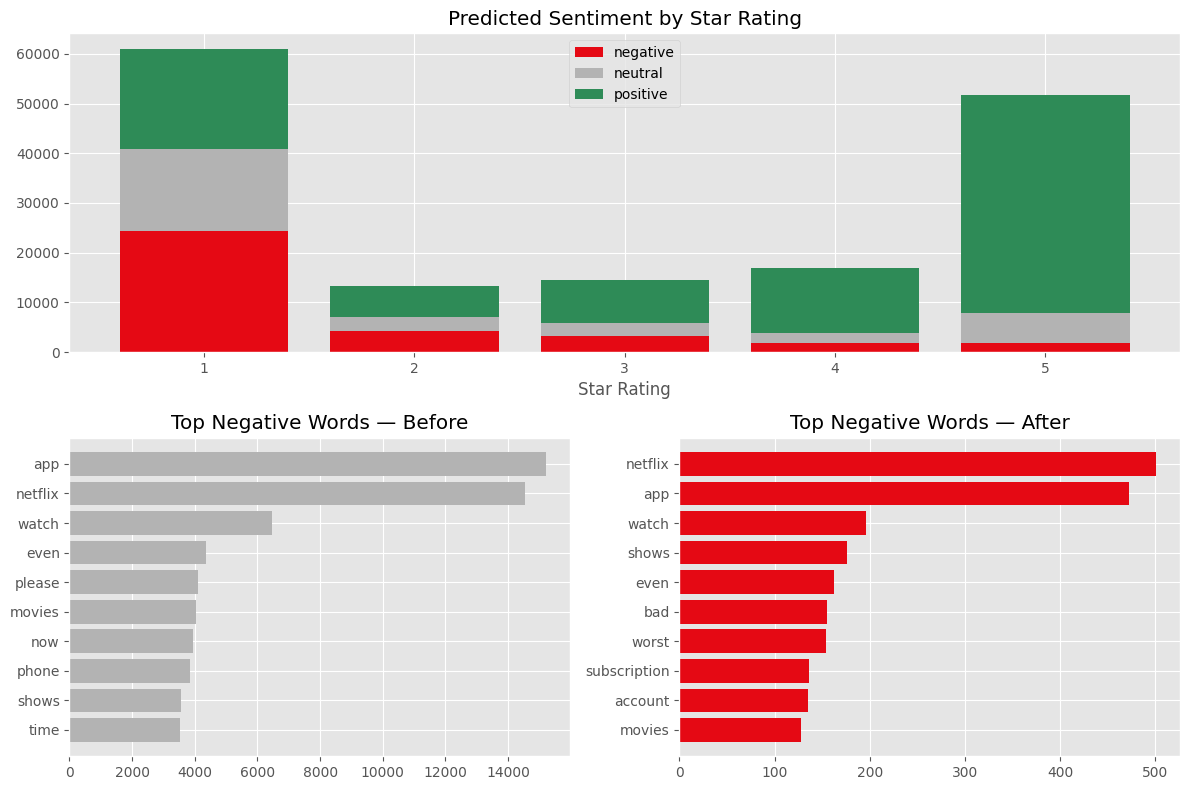

In [34]:
# Sentiment by star rating + top negative words before/after
def clean_words(text):
    words = text.lower().split()
    return [w.strip(".,!?\"'():;") for w in words if len(w.strip(".,!?\"'():;")) > 2 and w not in STOPWORDS]

def top_words(text_series, n=10):
    counts = {}
    for text in text_series:
        for word in clean_words(str(text)):
            counts[word] = counts.get(word, 0) + 1
    return sorted(counts.items(), key=lambda pair: pair[1], reverse=True)[:n]

neg_before = data[(data["Predicted_Sentiment_Label"] == "negative") & (data["Period"] == "Before Price Hike")][TEXT_COLUMN]
neg_after = data[(data["Predicted_Sentiment_Label"] == "negative") & (data["Period"] == "After Price Hike")][TEXT_COLUMN]
before_top, after_top = top_words(neg_before), top_words(neg_after)

fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])
ax1 = fig.add_subplot(gs[0, :])
bottom_for_positive = [negative_counts[i] + neutral_counts[i] for i in range(len(ratings))]
ax1.bar(ratings, negative_counts, color=NETFLIX_RED, label="negative")
ax1.bar(ratings, neutral_counts, bottom=negative_counts, color=NETFLIX_GRAY, label="neutral")
ax1.bar(ratings, positive_counts, bottom=bottom_for_positive, color=POSITIVE_GREEN, label="positive")
ax1.set_title("Predicted Sentiment by Star Rating")
ax1.set_xlabel("Star Rating")
ax1.legend()

ax2 = fig.add_subplot(gs[1, 0])
if before_top:
    words, counts = zip(*before_top)
    ax2.barh(words[::-1], counts[::-1], color=NETFLIX_GRAY)
ax2.set_title("Top Negative Words — Before")

ax3 = fig.add_subplot(gs[1, 1])
if after_top:
    words, counts = zip(*after_top)
    ax3.barh(words[::-1], counts[::-1], color=NETFLIX_RED)
ax3.set_title("Top Negative Words — After")
plt.tight_layout()
plt.savefig("rating_and_keywords.png", dpi=150, bbox_inches="tight")
plt.show()

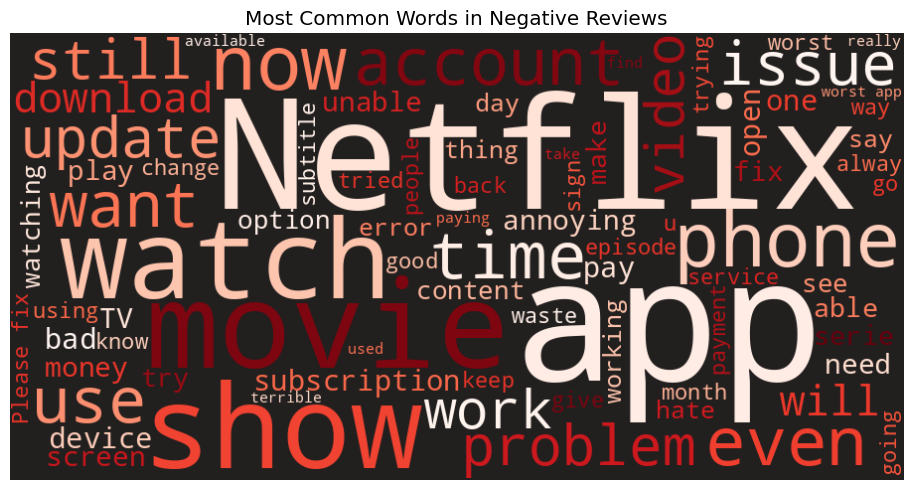

In [35]:
# Word cloud
negative_text = " ".join(data[data["Predicted_Sentiment_Label"] == "negative"][TEXT_COLUMN].astype(str))
wordcloud = WordCloud(width=900, height=450, background_color=NETFLIX_BLACK,
                       stopwords=STOPWORDS, colormap="Reds", max_words=80).generate(negative_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Negative Reviews")
plt.tight_layout()
plt.savefig("wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()

In [36]:
# ---- Save final results ----
data[TEXT_COLUMN] = data[TEXT_COLUMN].astype(str).str.replace("\n", " ").str.replace("\r", " ")
data.to_csv("netflix_sentiment_final.csv", index=False)
print(f"✅ Saved 'netflix_sentiment_final.csv' with {len(data)} rows.")

✅ Saved 'netflix_sentiment_final.csv' with 157624 rows.
